# Reel- Değerli Yapay Sinir Ağları (RDYSA) ile DNA-KODON- AMİNO ASİT Dizi Sınıflandırma
#### Açıklama: 
- Daha önce; İnsan vucuduna ait ve yaklaşık 500 ve üzeri protein çeşitliliği içeren Kinaz ve GPCR protein aileleri için UniProt uzantılı erişm (Acces) noları ile oluşturulan havuzdan herbir protein ailesi için basit rastgele örnekleme yöntemiyle (Simple Random Sampling) Train için 200 er örnek ve test için 100 er örnek seçilmiş; UniProt ve NCBI gen bankasından erişm (Acces) numaralarıyla CDS-DNA, KODON ve AMİNOASİT dizi formları fasta olarak indirilmiş; indirilen herbir dizi formuna ait örnekler, karşılaştırma amaçlı literatürde bilinen reel değerli Tam sayılı kodlama yöntemleri kullanılarak tamsayılara kodlanmış ve her bir dizi formu için .npz dosyasına train (Train toplam: 400) ve test (Test toplam: 200) olarak kaydedilmiştir.
- Bu bölümde ise; Tam sayı değerlerine dönüştürülmüş Kinaz ve GPCR proteinlerine ait DNA, KODON ve AMİNO ASİT dizileri Reel Değerli Yapay Sinir Ağları (RDYSA) kullanılarak sınıflandırılmasktadır. Sonuçlar grafiklerle görselleştirilmektedir. bir dosyada sonuçlar raporlanmaktadır.
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve .npz dosyasındaki veri setinin 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılmaktadır.


### Çalışma Adımları:

#### 1- RDYSA ile DNA dizisi sınıflandırma
- RDYSA ile Tam sayı değerlerine dönüştürülmüş DNA dizileri kullanılarak kinaz ve GPCR protein sınıflandırılması yapılmaktadır.

#### 2- RDYSA ile KODON dizisi sınıflandırma
- RDYSA ile Tam sayı değerlerine dönüştürülmüş KODON dizileri kullanılarak kinaz ve GPCR protein sınıflandırılması yapılmaktadır.

#### 3- RDYSA  ile AMİNO ASİT dizi Sınıflandırma
- RDYSA ile Tam sayı değerleri dönüştürülmüş AMİNO ASİT dizileri kullanılarak kinaz ve GPCR protein sınıflandırılması yapılmaktadır.ne



## 1) RDYSA ile tam sayı değerli DNA dizisi sınıflandırma:
- Daha önce karşılaştırma amaçlı literatürde bilinen reel değerli kodlama yöntemleri kullanılarak tamsayılara sayılara kodlanmış DNA dizilerine ait 400 train ve 200 test veri örneği kullanılarak kinaz (1) ve GPCR (0) protein aileleri RDYSA ile sınıflandırılmaktadır.
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılır. Sonuçlar grafiklerle görselleştirilir.

In [8]:
# ============================================
# Reel değerli Yapay Sinir Ağları (RDYSA) ile DNA sınıflandırma
# Veri kaynağı: cds_DNA_Reel_L900.npz   
# ======================================
# 1) 400 örnek üzerinde 10-fold CV
# 2) Aynı 400 örnekle final model eğitimi
# 3) Ayrı 200 örnek üzerinde final test
# GPCR = 0, Kinase = 1
#
# ============================================

import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import os
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# =======================================================
# uyarı azaltma
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")
# ------------------------------------------------------------
# Her çalıştırmada farklı seed
# ------------------------------------------------------------
def yeni_run_seedi() -> int:
    return int(time.time() * 1000) % 10_000_000 + random.randint(0, 100_000)

RUN_SEED = yeni_run_seedi()
SPLIT_SEED = 42   
print(f"[INFO] Bu run için kullanılan seed: {RUN_SEED}")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RUN_SEED)
np.random.seed(RUN_SEED)
random.seed(RUN_SEED)

# ------------------------------------------------------------
# Veri seti bilgisi
# ------------------------------------------------------------
NPZ_YOLU = r"C:\Users\matya\cds_DNA_Reel_L900.npz"

SINIF_ADLARI = {0: "GPCR", 1: "Kinase"}

# ------------------------------------------------------------
# Veri okuma  (.npz — )
# ------------------------------------------------------------
def veriyi_yukle_npz_reel(npz_yolu):
    d = np.load(npz_yolu, allow_pickle=False)

    def al(k):
        if k not in d.files:
            raise KeyError(f"'{k}' anahtarı .npz içinde yok. Mevcut: {list(d.files)}")
        return d[k]

    X_tr = al("X_egitim").astype(np.float32)   # kategori kodu 
    X_te = al("X_test").astype(np.float32)
    y_tr = al("y_egitim").astype(int)
    y_te = al("y_test").astype(int)
    return X_tr, y_tr, X_te, y_te


X_full_train, y_full_train, X_test, y_test = veriyi_yukle_npz_reel(NPZ_YOLU)

print("=== VERI BILGISI ===")
print(f"CV havuzu   : {X_full_train.shape[0]}  (girdi boyutu={X_full_train.shape[1]})")
print(f"Final test  : {X_test.shape[0]}")
print(f"GPCR/Kinase : egitim {np.sum(y_full_train==0)}/{np.sum(y_full_train==1)}  "
      f"test {np.sum(y_test==0)}/{np.sum(y_test==1)}")
print("====================\n")

# ------------------------------------------------------------
# Reel model
# ------------------------------------------------------------
def modeli_kur(giris_boyutu: int, seed: int) -> Sequential:
    tf.keras.utils.set_random_seed(seed)

    model = Sequential([
        Input(shape=(giris_boyutu,), name="giris"),
        Dense(units=12, activation="tanh", name="katman_12"),
        Dropout(0.5, name="drop_1"),
        Dense(units=8, activation="tanh", name="katman_8"),
        Dropout(0.5, name="drop_2"),
        Dense(units=6, activation="tanh", name="katman_6"),
        Dropout(0.5, name="drop_3"),
        Dense(units=1, activation="sigmoid", name="cikis")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.005),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ------------------------------------------------------------
# 10-Fold  CV
# ------------------------------------------------------------
N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SPLIT_SEED)

fold_sonuclari = []

for fold_no, (train_idx, val_idx) in enumerate(skf.split(X_full_train, y_full_train), start=1):
    print(f"\n================ FOLD {fold_no}/{N_SPLITS} ================")

    fold_seed = RUN_SEED + fold_no * 100

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(fold_seed)
    np.random.seed(fold_seed)
    random.seed(fold_seed)

    X_train_fold = X_full_train[train_idx]
    X_val_fold   = X_full_train[val_idx]

    y_train_fold = y_full_train[train_idx]
    y_val_fold   = y_full_train[val_idx]

    # Ölçekleme: sadece fold-train üzerinde fit
    sc = StandardScaler()
    X_train_fold = sc.fit_transform(X_train_fold)
    X_val_fold   = sc.transform(X_val_fold)

    print(f"Train boyutu      : {X_train_fold.shape[0]}")
    print(f"Validation boyutu : {X_val_fold.shape[0]}")

    model = modeli_kur(giris_boyutu=X_train_fold.shape[1], seed=fold_seed)

    callbacks = [
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=8,
            min_lr=1e-5,
            verbose=0
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=25,
            restore_best_weights=True,
            verbose=0
        )
    ]

    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        batch_size=10,
        epochs=80,
        callbacks=callbacks,
        verbose=0
    )

    # Fold validation tahmini
    y_val_pred_proba = model.predict(X_val_fold, verbose=0).ravel()
    y_val_pred = (y_val_pred_proba >= 0.5).astype(int)

    fold_acc = accuracy_score(y_val_fold, y_val_pred)

    # Sınıf bazlı
    prec_cls, rec_cls, f1_cls, sup_cls = precision_recall_fscore_support(
        y_val_fold, y_val_pred,
        labels=[0, 1],
        average=None,
        zero_division=0
    )

    # Macro
    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
        y_val_fold, y_val_pred,
        average="macro",
        zero_division=0
    )

    fold_dict = {
        "fold": fold_no,
        "acc": fold_acc,
        "macro_precision": macro_prec,
        "macro_recall": macro_rec,
        "macro_f1": macro_f1,

        "gpcr_precision": prec_cls[0],
        "gpcr_recall": rec_cls[0],
        "gpcr_f1": f1_cls[0],
        "gpcr_support": sup_cls[0],

        "kinase_precision": prec_cls[1],
        "kinase_recall": rec_cls[1],
        "kinase_f1": f1_cls[1],
        "kinase_support": sup_cls[1],

        "best_val_loss": float(np.min(history.history["val_loss"])),
        "best_val_acc": float(np.max(history.history["val_accuracy"])),
        "epoch_sayisi": len(history.history["loss"])
    }

    fold_sonuclari.append(fold_dict)

    print(f"Fold Accuracy      : {fold_acc:.4f}")
    print(f"Fold Macro F1      : {macro_f1:.4f}")
    print(f"GPCR   F1          : {f1_cls[0]:.4f}")
    print(f"Kinase F1          : {f1_cls[1]:.4f}")
    print(f"Best Val Loss      : {fold_dict['best_val_loss']:.4f}")
    print(f"Best Val Acc       : {fold_dict['best_val_acc']:.4f}")
    print(f"Epoch Sayisi       : {fold_dict['epoch_sayisi']}")

# ------------------------------------------------------------
# CV sonuç tablosu
# ------------------------------------------------------------
cv_df = pd.DataFrame(fold_sonuclari)

print("\n================ 10-FOLD CV SONUCLARI =================")
print(cv_df[[
    "fold", "acc", "macro_precision", "macro_recall", "macro_f1",
    "gpcr_precision", "gpcr_recall", "gpcr_f1",
    "kinase_precision", "kinase_recall", "kinase_f1",
    "best_val_loss", "best_val_acc", "epoch_sayisi"
]].round(4))

print("\n================ CV ORTALAMA ± STD =================")
for kolon in [
    "acc", "macro_precision", "macro_recall", "macro_f1",
    "gpcr_precision", "gpcr_recall", "gpcr_f1",
    "kinase_precision", "kinase_recall", "kinase_f1",
    "best_val_loss", "best_val_acc", "epoch_sayisi"
]:
    ort = cv_df[kolon].mean()
    std = cv_df[kolon].std(ddof=1)
    print(f"{kolon:18s}: {ort:.4f} ± {std:.4f}")

# Paired istatistiksel karşılaştırma için fold sonuçları kaydedilir
cv_df.to_excel("reel_dna_cv_10_fold_npz.xlsx", index=False)

# ------------------------------------------------------------
# Final model eğitimi
# 400 örnek kullanılır, %10 iç validation ayrılır
# ------------------------------------------------------------
print("\n================ FINAL MODEL EGITIMI =================")

final_seed = RUN_SEED + 9999

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(final_seed)
np.random.seed(final_seed)
random.seed(final_seed)

X_final_train, X_final_val, y_final_train, y_final_val = train_test_split(
    X_full_train,
    y_full_train,
    test_size=0.10,
    shuffle=True,
    stratify=y_full_train,
    random_state=final_seed
)

# Ölçekleme: sadece final-train üzerinde fit
sc_final = StandardScaler()
X_final_train = sc_final.fit_transform(X_final_train)
X_final_val   = sc_final.transform(X_final_val)
X_test_scaled = sc_final.transform(X_test)

final_model = modeli_kur(giris_boyutu=X_final_train.shape[1], seed=final_seed)

final_callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-5,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

final_history = final_model.fit(
    X_final_train, y_final_train,
    validation_data=(X_final_val, y_final_val),
    batch_size=10,
    epochs=80,
    callbacks=final_callbacks,
    verbose=1
)

# ------------------------------------------------------------
# Final test
# ------------------------------------------------------------
test_eval = final_model.evaluate(X_test_scaled, y_test, verbose=0)
print("\n[INFO] Final test evaluate çıktısı:", test_eval)

y_test_pred_proba = final_model.predict(X_test_scaled, verbose=0).ravel()
y_test_pred = (y_test_pred_proba >= 0.5).astype(int)

test_cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
test_acc = accuracy_score(y_test, y_test_pred)

test_prec_cls, test_rec_cls, test_f1_cls, test_sup_cls = precision_recall_fscore_support(
    y_test, y_test_pred,
    labels=[0, 1],
    average=None,
    zero_division=0
)

test_macro_prec, test_macro_rec, test_macro_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred,
    average="macro",
    zero_division=0
)

print("\n================ FINAL TEST SONUCU =================")
print("Confusion Matrix:\n", test_cm)
print(f"Test Accuracy     : {test_acc:.4f}")
print(f"Test Macro Prec   : {test_macro_prec:.4f}")
print(f"Test Macro Recall : {test_macro_rec:.4f}")
print(f"Test Macro F1     : {test_macro_f1:.4f}\n")

for i, lab in enumerate([0, 1]):
    print(
        f"- {SINIF_ADLARI[lab]} (label={lab}) | "
        f"Precision: {test_prec_cls[i]:.4f} | "
        f"Recall: {test_rec_cls[i]:.4f} | "
        f"F1: {test_f1_cls[i]:.4f} | "
        f"Support: {test_sup_cls[i]}"
    )

[INFO] Bu run için kullanılan seed: 4582097
=== VERI BILGISI ===
CV havuzu   : 400  (girdi boyutu=900)
Final test  : 200
GPCR/Kinase : egitim 200/200  test 100/100


================ FOLD 1/10 ================
Train boyutu      : 360
Validation boyutu : 40
Fold Accuracy      : 0.9500
Fold Macro F1      : 0.9499
GPCR   F1          : 0.9474
Kinase F1          : 0.9524
Best Val Loss      : 0.2039
Best Val Acc       : 0.9500
Epoch Sayisi       : 33

================ FOLD 2/10 ================
Train boyutu      : 360
Validation boyutu : 40
Fold Accuracy      : 0.9000
Fold Macro F1      : 0.8997
GPCR   F1          : 0.8947
Kinase F1          : 0.9048
Best Val Loss      : 0.2989
Best Val Acc       : 0.9000
Epoch Sayisi       : 36

================ FOLD 3/10 ================
Train boyutu      : 360
Validation boyutu : 40
Fold Accuracy      : 0.8000
Fold Macro F1      : 0.7917
GPCR   F1          : 0.7500
Kinase F1          : 0.8333
Best Val Loss      : 0.5323
Best Val Acc       : 0.8250
Epoch S

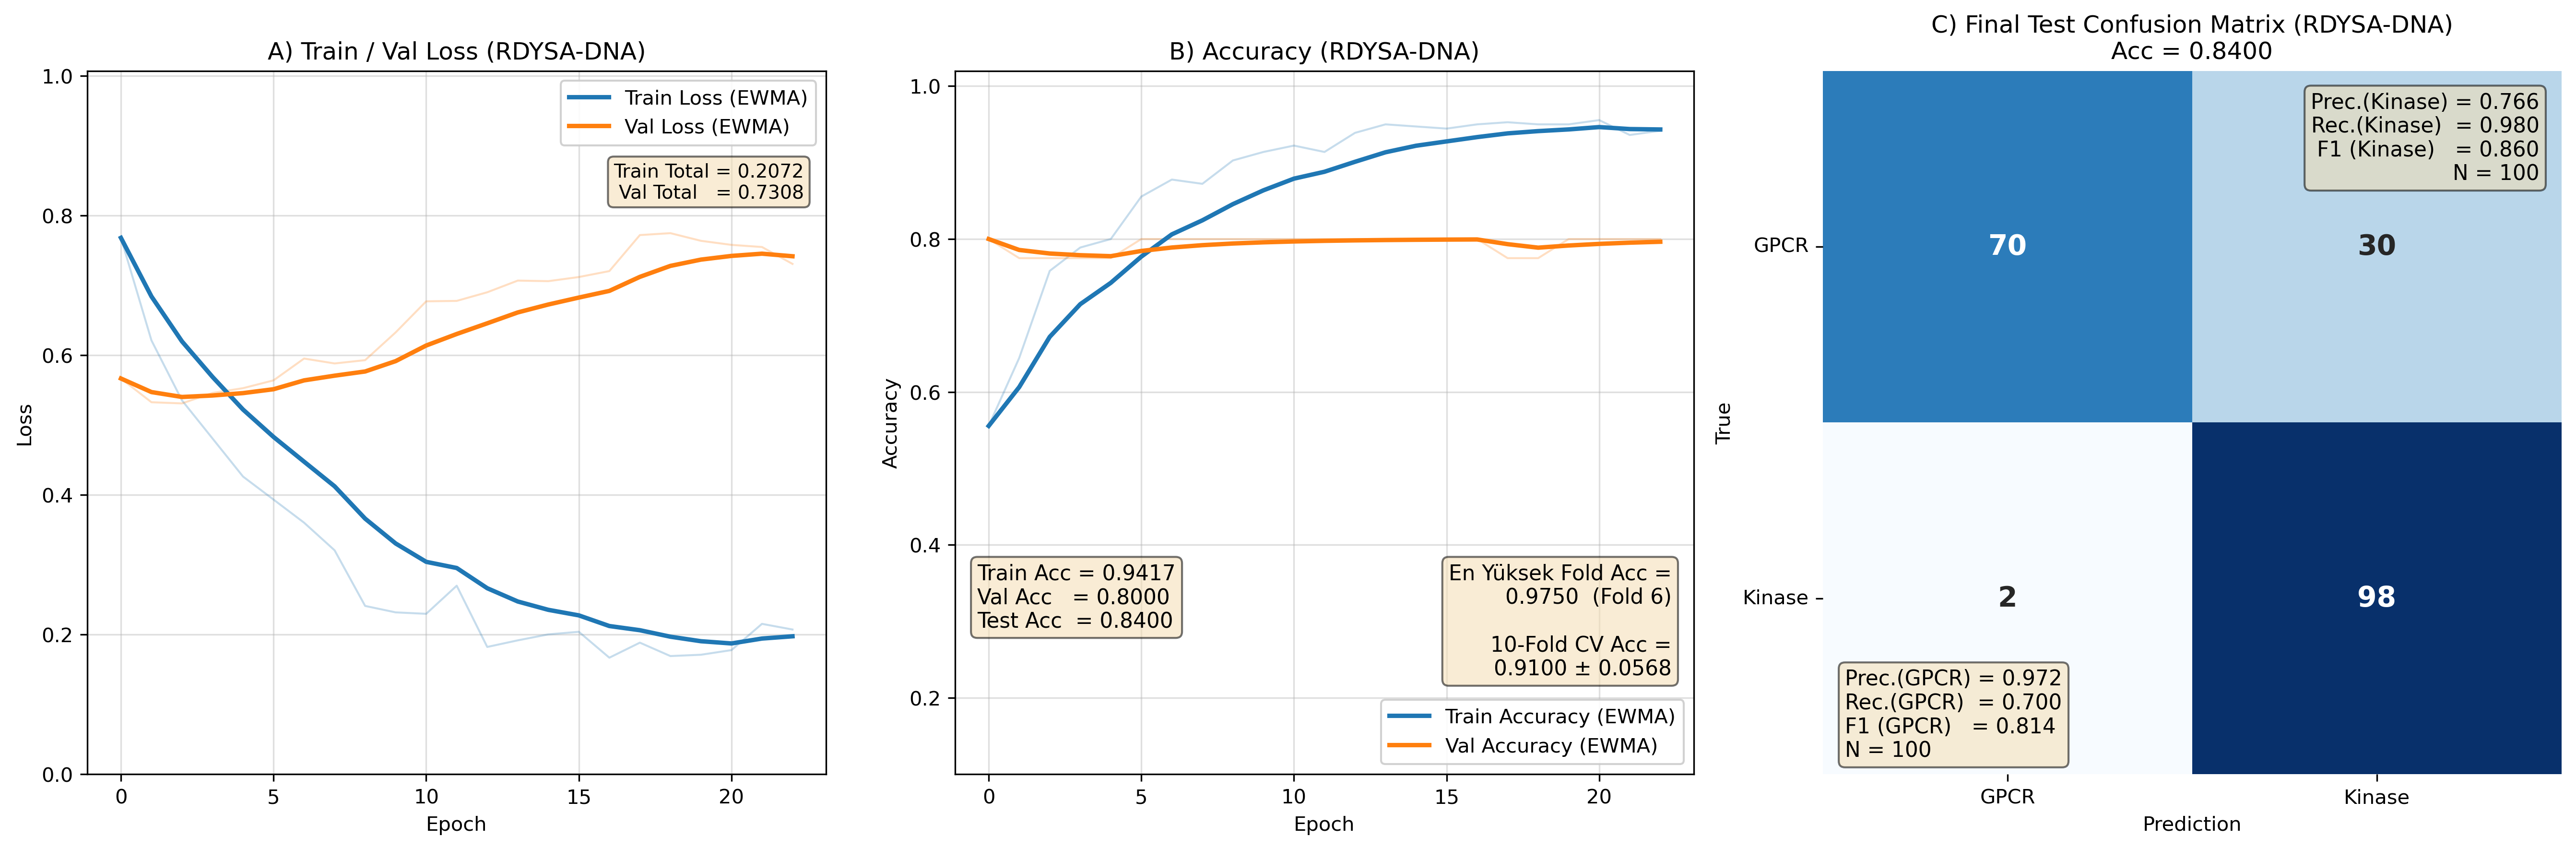

In [9]:
# =============================================================================
#   GRAFİK GÖRSELLEŞTİRME — RDYSA (Reel Değerli YSA)   (DNA / Kodon / AA ortak )
#
#   Panel A : Train / Val Loss (EWMA yumuşatmalı)
#   Panel B : Accuracy (EWMA yumuşatmalı)
#   Panel C : Confusion Matrix + sınıf bazlı metrik kutuları
#

# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support,
    accuracy_score, f1_score
)


# -------------------------------------------------------------------------
# 0.  Temsil etiketi  (DNA / Kodon / AA)
#     Ağ scriptindeki NPZ_YOLU'ndan otomatik algıla
# -------------------------------------------------------------------------
try:
    _kaynak = str(NPZ_YOLU).upper()
    if   "DNA"   in _kaynak: TEMSIL = "DNA"
    elif "KODON" in _kaynak: TEMSIL = "Kodon"
    elif "AA"    in _kaynak: TEMSIL = "AA"
    else:                    TEMSIL = "Reel"
except NameError:
    TEMSIL = "DNA"   # NPZ_YOLU  


# -------------------------------------------------------------------------
# 1.  History anahtarları
# -------------------------------------------------------------------------
LOSS_KEY     = "loss"
VAL_LOSS_KEY = "val_loss"
ACC_KEY      = "accuracy"
VAL_ACC_KEY  = "val_accuracy"


# -------------------------------------------------------------------------
# 2.  EWMA yumuşatma
# -------------------------------------------------------------------------
def ewma_yumusat(dizi, alpha: float = 0.25) -> np.ndarray:
    return pd.Series(np.asarray(dizi, dtype=float)) \
             .ewm(alpha=alpha, adjust=True).mean().values


h = final_history.history
train_loss_ham = np.asarray(h[LOSS_KEY],     dtype=float)
val_loss_ham   = np.asarray(h[VAL_LOSS_KEY], dtype=float)
train_acc_ham  = np.asarray(h[ACC_KEY],      dtype=float)
val_acc_ham    = np.asarray(h[VAL_ACC_KEY],  dtype=float)

train_loss_sm = ewma_yumusat(train_loss_ham, alpha=0.25)
val_loss_sm   = ewma_yumusat(val_loss_ham,   alpha=0.25)
train_acc_sm  = ewma_yumusat(train_acc_ham,  alpha=0.25)
val_acc_sm    = ewma_yumusat(val_acc_ham,    alpha=0.25)


# -------------------------------------------------------------------------
# 3.  Son epoch değerleri
# -------------------------------------------------------------------------
train_loss_son = float(train_loss_ham[-1])
val_loss_son   = float(val_loss_ham[-1])
train_acc_son  = float(train_acc_ham[-1])
val_acc_son    = float(val_acc_ham[-1])


# -------------------------------------------------------------------------
# 4.  Test metrikleri
# -------------------------------------------------------------------------
y_true = y_test
y_pred = y_test_pred

cm  = confusion_matrix(y_true, y_pred, labels=[0, 1])
acc = accuracy_score(y_true, y_pred)

prec, rec, f1, sup = precision_recall_fscore_support(
    y_true, y_pred,
    labels=[0, 1], average=None, zero_division=0)
macro_f1_test = f1_score(y_true, y_pred, average="macro", zero_division=0)


# -------------------------------------------------------------------------
# 5.  CV özet
# -------------------------------------------------------------------------
cv_acc_mean        = cv_df["acc"].mean()
cv_acc_std         = cv_df["acc"].std(ddof=1)
cv_best_val_loss_mean = cv_df["best_val_loss"].mean()
cv_best_val_loss_std  = cv_df["best_val_loss"].std(ddof=1)
cv_best_val_acc_mean  = cv_df["best_val_acc"].mean()
cv_best_val_acc_std   = cv_df["best_val_acc"].std(ddof=1)
en_yuksek_fold_acc = cv_df["acc"].max()
en_yuksek_fold_no  = int(cv_df.loc[cv_df["acc"].idxmax(), "fold"])


# -------------------------------------------------------------------------
# 6.  Metin kutuları
# -------------------------------------------------------------------------
props = dict(boxstyle="round", facecolor="wheat", alpha=0.55)

# ── Panel A: Train / Val Total Loss ──────────────────────────────────────
text_loss = "\n".join((
    f"Train Total = {train_loss_son:.4f}",
    f"Val Total   = {val_loss_son:.4f}",
))

# ── Panel B kutu 1: Train / Val / Test Acc ───────────────────────────────
text_acc_1 = "\n".join((
    f"Train Acc = {train_acc_son:.4f}",
    f"Val Acc   = {val_acc_son:.4f}",
    f"Test Acc  = {acc:.4f}",
))

# ── Panel B kutu 2: Fold istatistikleri ──────────────────────────────────
text_acc_2 = "\n".join((
    f"En Yüksek Fold Acc =",
    f"{en_yuksek_fold_acc:.4f}  (Fold {en_yuksek_fold_no})",
    "",
    f"10-Fold CV Acc =",
    f"{cv_acc_mean:.4f} ± {cv_acc_std:.4f}",
))

# ── Panel C: Sınıf kutuları ───────────────────────────────────────────────
text_gpcr = "\n".join((
    f"Prec.(GPCR) = {prec[0]:.3f}",
    f"Rec.(GPCR)  = {rec[0]:.3f}",
    f"F1 (GPCR)   = {f1[0]:.3f}",
    f"N = {sup[0]}",
))

text_kinase = "\n".join((
    f"Prec.(Kinase) = {prec[1]:.3f}",
    f"Rec.(Kinase)  = {rec[1]:.3f}",
    f"F1 (Kinase)   = {f1[1]:.3f}",
    f"N = {sup[1]}",
))


# -------------------------------------------------------------------------
# 7.  Grafik
# -------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

C_TRAIN = "#1f77b4"
C_VAL   = "#ff7f0e"

# ==========================================================================
#  A) Train / Val Loss
# ==========================================================================
ax[0].plot(train_loss_ham, color=C_TRAIN, linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[0].plot(val_loss_ham,   color=C_VAL,   linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[0].plot(train_loss_sm,  color=C_TRAIN, linewidth=2.2,
           label="Train Loss (EWMA)")
ax[0].plot(val_loss_sm,    color=C_VAL,   linewidth=2.2,
           label="Val Loss (EWMA)")

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.4)
ax[0].legend(loc="upper right", framealpha=0.9)
ax[0].set_title(f"A) Train / Val Loss (RDYSA-{TEMSIL})")

ymax_loss = max(np.max(train_loss_ham), np.max(val_loss_ham))
ax[0].set_ylim(0.0, max(0.5, ymax_loss * 1.30))

ax[0].text(0.97, 0.87, text_loss,
           transform=ax[0].transAxes, ha="right", va="top",
           fontsize=9.5, bbox=props)

# ==========================================================================
#  B) Accuracy
# ==========================================================================
ax[1].plot(train_acc_ham, color=C_TRAIN, linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[1].plot(val_acc_ham,   color=C_VAL,   linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[1].plot(train_acc_sm,  color=C_TRAIN, linewidth=2.2,
           label="Train Accuracy (EWMA)")
ax[1].plot(val_acc_sm,    color=C_VAL,   linewidth=2.2,
           label="Val Accuracy (EWMA)")

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].grid(True, alpha=0.4)
ax[1].legend(loc="lower right", framealpha=0.9)
ax[1].set_title(f"B) Accuracy (RDYSA-{TEMSIL})")
ax[1].set_ylim(0.1, 1.02)

# Kutu 1: Train / Val / Test Acc — sol alt
ax[1].text(0.03, 0.30, text_acc_1,
           transform=ax[1].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)

# Kutu 2: Fold istatistikleri — sağ alt
ax[1].text(0.97, 0.30, text_acc_2,
           transform=ax[1].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

# ==========================================================================
#  C) Confusion Matrix
# ==========================================================================
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            cbar=False, ax=ax[2],
            annot_kws={"size": 14, "weight": "bold"})

ax[2].set_xlabel("Prediction")
ax[2].set_ylabel("True")
ax[2].set_title(
    f"C) Final Test Confusion Matrix (RDYSA-{TEMSIL})\nAcc = {acc:.4f}")
ax[2].set_xticklabels([SINIF_ADLARI.get(0, "0"), SINIF_ADLARI.get(1, "1")])
ax[2].set_yticklabels([SINIF_ADLARI.get(0, "0"), SINIF_ADLARI.get(1, "1")],
                      rotation=0)

ax[2].text(0.03, 0.15, text_gpcr,
           transform=ax[2].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)
ax[2].text(0.97, 0.97, text_kinase,
           transform=ax[2].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

plt.tight_layout()
plt.savefig(f"reel_ag_{TEMSIL.lower()}_train_val_test_sonuclari.png",
            dpi=600, bbox_inches="tight")
plt.show()

## 2) RDYSA ile tam sayı değerli KODON dizisi sınıflandırma:
- Daha önce karşılaştırma amaçlı literatürde bilinen reel değerli reel yöntemler kullanılarak tam sayılara  kodlanmış KODON dizilerine ait 400 train ve 200 test veri örneği kullanılarak kinaz (1) ve GPCR (0) protein aileleri RDYSA ile sınıflandırılmaktadır.
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılır.
- Eğitim (train) ve Doğrulama (Val.) ve Son olarak Final Test için Accuracy oranları hesaplanmakta ve her iki sınıf için ayrı ayrı Precision/Recall/F1 hesaplanmaktadır.
- Sonuçlar grafiklerle görselleştirilir.

In [10]:
# ============================================
# Reel değerli Yapay Sinir Ağları (RDYSA) ile Kodon sınıflandırma
# Veri kaynağı: cds_KODON_Reel_L900.npz   
# ======================================
# 1) 400 örnek üzerinde 10-fold CV
# 2) Aynı 400 örnekle final model eğitimi
# 3) Ayrı 200 örnek üzerinde final test
# GPCR = 0, Kinase = 1

# ============================================

import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import os
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# =======================================================
# uyarı azaltma
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")
# ------------------------------------------------------------
# Her çalıştırmada farklı seed
# ------------------------------------------------------------
def yeni_run_seedi() -> int:
    return int(time.time() * 1000) % 10_000_000 + random.randint(0, 100_000)

RUN_SEED = yeni_run_seedi()
SPLIT_SEED = 42   # 12 script'te de AYNI; eşleştirilmiş karşılaştırma için sabit
print(f"[INFO] Bu run için kullanılan seed: {RUN_SEED}")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RUN_SEED)
np.random.seed(RUN_SEED)
random.seed(RUN_SEED)

# ------------------------------------------------------------
# Veri seti bilgisi
# ------------------------------------------------------------
NPZ_YOLU = r"C:\Users\matya\cds_KODON_Reel_L900.npz"

SINIF_ADLARI = {0: "GPCR", 1: "Kinase"}

# ------------------------------------------------------------
# Veri okuma  (.npz — )
# ------------------------------------------------------------
def veriyi_yukle_npz_reel(npz_yolu):
    d = np.load(npz_yolu, allow_pickle=False)

    def al(k):
        if k not in d.files:
            raise KeyError(f"'{k}' anahtarı .npz içinde yok. Mevcut: {list(d.files)}")
        return d[k]

    X_tr = al("X_egitim").astype(np.float32)   # kategori kodu (büyüklük değil)
    X_te = al("X_test").astype(np.float32)
    y_tr = al("y_egitim").astype(int)
    y_te = al("y_test").astype(int)
    return X_tr, y_tr, X_te, y_te


X_full_train, y_full_train, X_test, y_test = veriyi_yukle_npz_reel(NPZ_YOLU)

print("=== VERI BILGISI ===")
print(f"CV havuzu   : {X_full_train.shape[0]}  (girdi boyutu={X_full_train.shape[1]})")
print(f"Final test  : {X_test.shape[0]}")
print(f"GPCR/Kinase : egitim {np.sum(y_full_train==0)}/{np.sum(y_full_train==1)}  "
      f"test {np.sum(y_test==0)}/{np.sum(y_test==1)}")
print("====================\n")

# ------------------------------------------------------------
# Reel model
# ------------------------------------------------------------
def modeli_kur(giris_boyutu: int, seed: int) -> Sequential:
    tf.keras.utils.set_random_seed(seed)

    model = Sequential([
        Input(shape=(giris_boyutu,), name="giris"),
        Dense(units=12, activation="tanh", name="katman_12"),
        Dropout(0.5, name="drop_1"),
        Dense(units=8, activation="tanh", name="katman_8"),
        Dropout(0.5, name="drop_2"),
        Dense(units=6, activation="tanh", name="katman_6"),
        Dropout(0.5, name="drop_3"),
        Dense(units=1, activation="sigmoid", name="cikis")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.005),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ------------------------------------------------------------
# 10-Fold  CV
# ------------------------------------------------------------
N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SPLIT_SEED)

fold_sonuclari = []

for fold_no, (train_idx, val_idx) in enumerate(skf.split(X_full_train, y_full_train), start=1):
    print(f"\n================ FOLD {fold_no}/{N_SPLITS} ================")

    fold_seed = RUN_SEED + fold_no * 100

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(fold_seed)
    np.random.seed(fold_seed)
    random.seed(fold_seed)

    X_train_fold = X_full_train[train_idx]
    X_val_fold   = X_full_train[val_idx]

    y_train_fold = y_full_train[train_idx]
    y_val_fold   = y_full_train[val_idx]

    # Ölçekleme: sadece fold-train üzerinde fit
    sc = StandardScaler()
    X_train_fold = sc.fit_transform(X_train_fold)
    X_val_fold   = sc.transform(X_val_fold)

    print(f"Train boyutu      : {X_train_fold.shape[0]}")
    print(f"Validation boyutu : {X_val_fold.shape[0]}")

    model = modeli_kur(giris_boyutu=X_train_fold.shape[1], seed=fold_seed)

    callbacks = [
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=8,
            min_lr=1e-5,
            verbose=0
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=25,
            restore_best_weights=True,
            verbose=0
        )
    ]

    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        batch_size=10,
        epochs=80,
        callbacks=callbacks,
        verbose=0
    )

    # Fold validation tahmini
    y_val_pred_proba = model.predict(X_val_fold, verbose=0).ravel()
    y_val_pred = (y_val_pred_proba >= 0.5).astype(int)

    fold_acc = accuracy_score(y_val_fold, y_val_pred)

    # Sınıf bazlı
    prec_cls, rec_cls, f1_cls, sup_cls = precision_recall_fscore_support(
        y_val_fold, y_val_pred,
        labels=[0, 1],
        average=None,
        zero_division=0
    )

    # Macro
    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
        y_val_fold, y_val_pred,
        average="macro",
        zero_division=0
    )

    fold_dict = {
        "fold": fold_no,
        "acc": fold_acc,
        "macro_precision": macro_prec,
        "macro_recall": macro_rec,
        "macro_f1": macro_f1,

        "gpcr_precision": prec_cls[0],
        "gpcr_recall": rec_cls[0],
        "gpcr_f1": f1_cls[0],
        "gpcr_support": sup_cls[0],

        "kinase_precision": prec_cls[1],
        "kinase_recall": rec_cls[1],
        "kinase_f1": f1_cls[1],
        "kinase_support": sup_cls[1],

        "best_val_loss": float(np.min(history.history["val_loss"])),
        "best_val_acc": float(np.max(history.history["val_accuracy"])),
        "epoch_sayisi": len(history.history["loss"])
    }

    fold_sonuclari.append(fold_dict)

    print(f"Fold Accuracy      : {fold_acc:.4f}")
    print(f"Fold Macro F1      : {macro_f1:.4f}")
    print(f"GPCR   F1          : {f1_cls[0]:.4f}")
    print(f"Kinase F1          : {f1_cls[1]:.4f}")
    print(f"Best Val Loss      : {fold_dict['best_val_loss']:.4f}")
    print(f"Best Val Acc       : {fold_dict['best_val_acc']:.4f}")
    print(f"Epoch Sayisi       : {fold_dict['epoch_sayisi']}")

# ------------------------------------------------------------
# CV sonuç tablosu
# ------------------------------------------------------------
cv_df = pd.DataFrame(fold_sonuclari)

print("\n================ 10-FOLD CV SONUCLARI =================")
print(cv_df[[
    "fold", "acc", "macro_precision", "macro_recall", "macro_f1",
    "gpcr_precision", "gpcr_recall", "gpcr_f1",
    "kinase_precision", "kinase_recall", "kinase_f1",
    "best_val_loss", "best_val_acc", "epoch_sayisi"
]].round(4))

print("\n================ CV ORTALAMA ± STD =================")
for kolon in [
    "acc", "macro_precision", "macro_recall", "macro_f1",
    "gpcr_precision", "gpcr_recall", "gpcr_f1",
    "kinase_precision", "kinase_recall", "kinase_f1",
    "best_val_loss", "best_val_acc", "epoch_sayisi"
]:
    ort = cv_df[kolon].mean()
    std = cv_df[kolon].std(ddof=1)
    print(f"{kolon:18s}: {ort:.4f} ± {std:.4f}")

# Paired istatistiksel karşılaştırma için fold sonuçları kaydedilir
cv_df.to_excel("reel_kodon_cv_10_fold_npz.xlsx", index=False)

# ------------------------------------------------------------
# Final model eğitimi
# 400 örnek tekrar kullanılır, %10 iç validation ayrılır
# ------------------------------------------------------------
print("\n================ FINAL MODEL EGITIMI =================")

final_seed = RUN_SEED + 9999

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(final_seed)
np.random.seed(final_seed)
random.seed(final_seed)

X_final_train, X_final_val, y_final_train, y_final_val = train_test_split(
    X_full_train,
    y_full_train,
    test_size=0.10,
    shuffle=True,
    stratify=y_full_train,
    random_state=final_seed
)

# Ölçekleme: sadece final-train üzerinde fit
sc_final = StandardScaler()
X_final_train = sc_final.fit_transform(X_final_train)
X_final_val   = sc_final.transform(X_final_val)
X_test_scaled = sc_final.transform(X_test)

final_model = modeli_kur(giris_boyutu=X_final_train.shape[1], seed=final_seed)

final_callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-5,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

final_history = final_model.fit(
    X_final_train, y_final_train,
    validation_data=(X_final_val, y_final_val),
    batch_size=10,
    epochs=80,
    callbacks=final_callbacks,
    verbose=1
)

# ------------------------------------------------------------
# Final test
# ------------------------------------------------------------
test_eval = final_model.evaluate(X_test_scaled, y_test, verbose=0)
print("\n[INFO] Final test evaluate çıktısı:", test_eval)

y_test_pred_proba = final_model.predict(X_test_scaled, verbose=0).ravel()
y_test_pred = (y_test_pred_proba >= 0.5).astype(int)

test_cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
test_acc = accuracy_score(y_test, y_test_pred)

test_prec_cls, test_rec_cls, test_f1_cls, test_sup_cls = precision_recall_fscore_support(
    y_test, y_test_pred,
    labels=[0, 1],
    average=None,
    zero_division=0
)

test_macro_prec, test_macro_rec, test_macro_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred,
    average="macro",
    zero_division=0
)

print("\n================ FINAL TEST SONUCU =================")
print("Confusion Matrix:\n", test_cm)
print(f"Test Accuracy     : {test_acc:.4f}")
print(f"Test Macro Prec   : {test_macro_prec:.4f}")
print(f"Test Macro Recall : {test_macro_rec:.4f}")
print(f"Test Macro F1     : {test_macro_f1:.4f}\n")

for i, lab in enumerate([0, 1]):
    print(
        f"- {SINIF_ADLARI[lab]} (label={lab}) | "
        f"Precision: {test_prec_cls[i]:.4f} | "
        f"Recall: {test_rec_cls[i]:.4f} | "
        f"F1: {test_f1_cls[i]:.4f} | "
        f"Support: {test_sup_cls[i]}"
    )

[INFO] Bu run için kullanılan seed: 5209986
=== VERI BILGISI ===
CV havuzu   : 400  (girdi boyutu=300)
Final test  : 200
GPCR/Kinase : egitim 200/200  test 100/100


================ FOLD 1/10 ================
Train boyutu      : 360
Validation boyutu : 40
Fold Accuracy      : 0.9000
Fold Macro F1      : 0.9000
GPCR   F1          : 0.9000
Kinase F1          : 0.9000
Best Val Loss      : 0.2405
Best Val Acc       : 0.9000
Epoch Sayisi       : 31

================ FOLD 2/10 ================
Train boyutu      : 360
Validation boyutu : 40
Fold Accuracy      : 0.8750
Fold Macro F1      : 0.8743
GPCR   F1          : 0.8649
Kinase F1          : 0.8837
Best Val Loss      : 0.3493
Best Val Acc       : 0.9000
Epoch Sayisi       : 33

================ FOLD 3/10 ================
Train boyutu      : 360
Validation boyutu : 40
Fold Accuracy      : 0.8000
Fold Macro F1      : 0.7954
GPCR   F1          : 0.7647
Kinase F1          : 0.8261
Best Val Loss      : 0.4641
Best Val Acc       : 0.8000
Epoch S

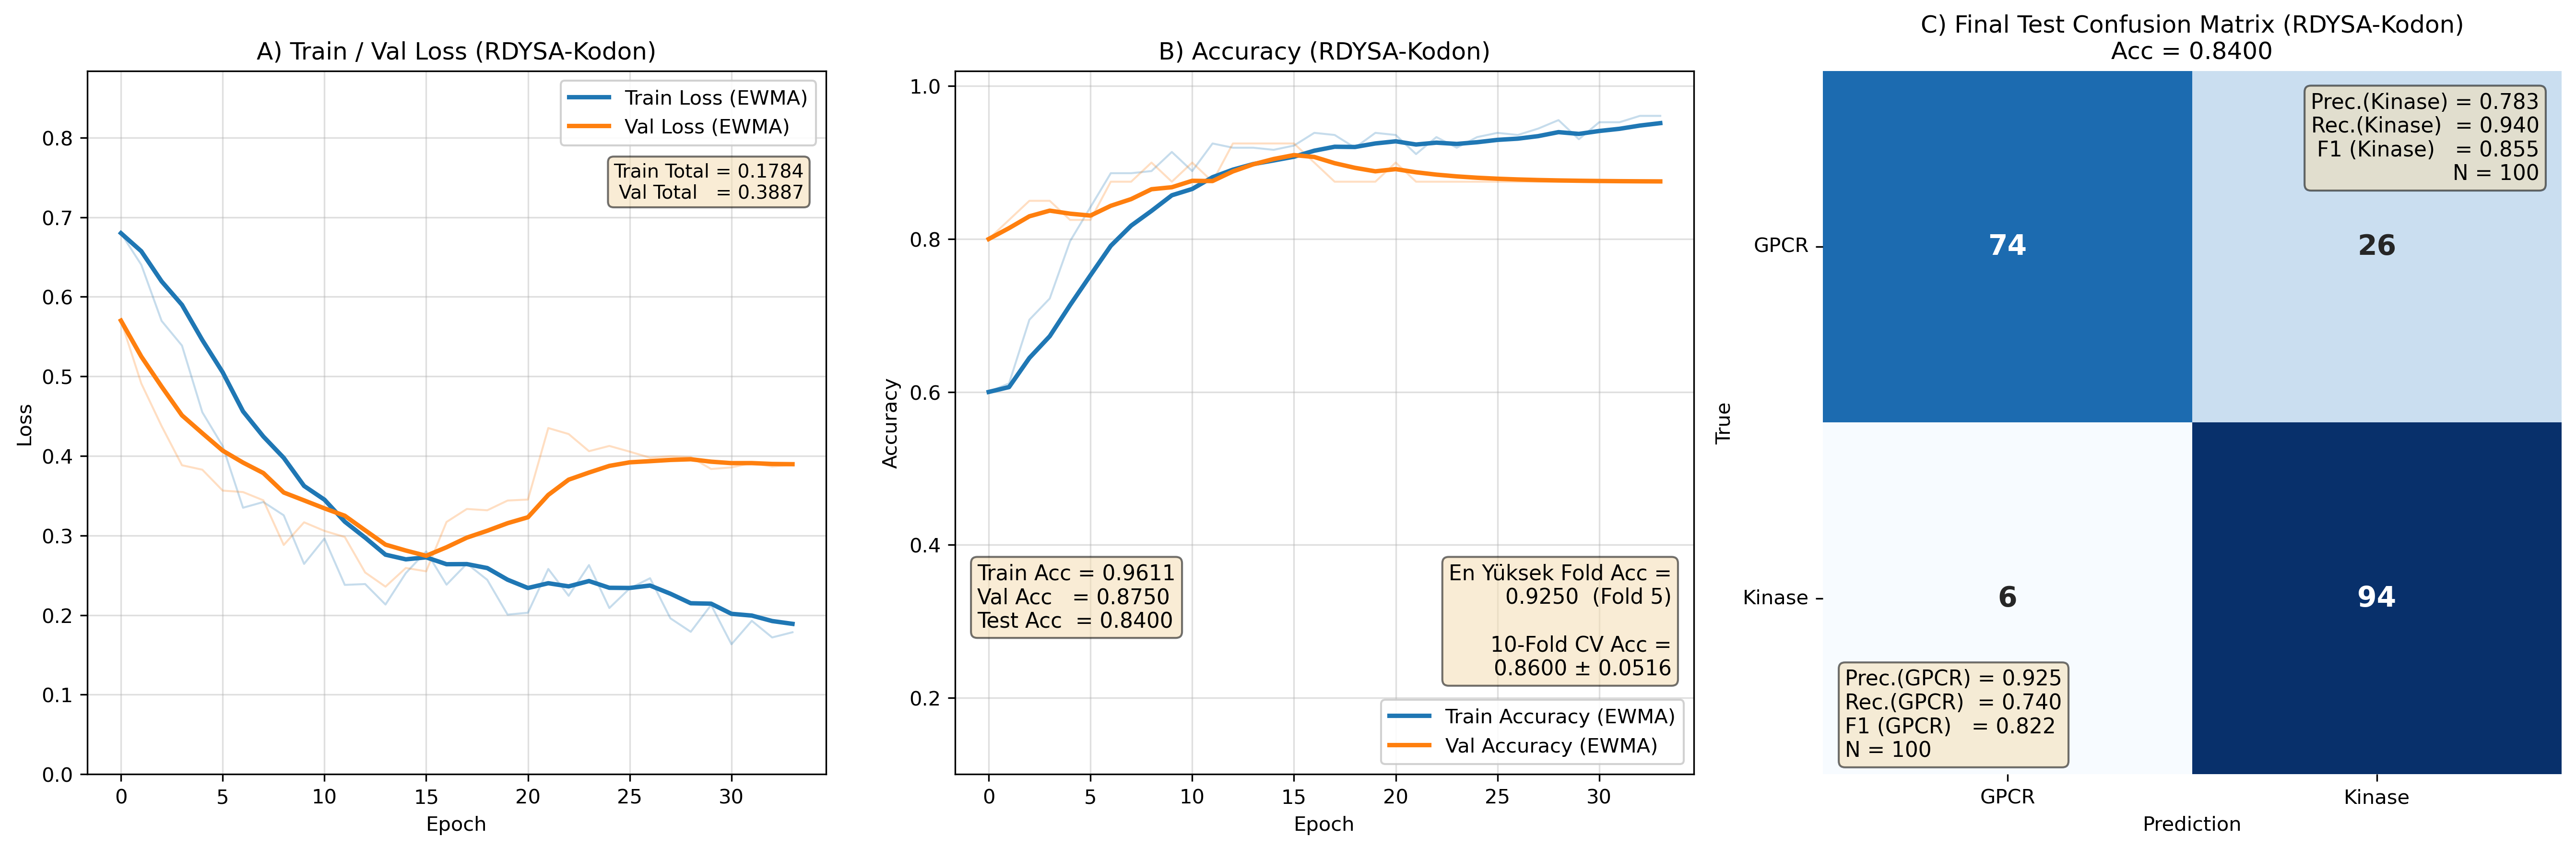

In [11]:
# =============================================================================
#   GRAFİK GÖRSELLEŞTİRME — RDYSA (Reel Değerli YSA)   [DNA / Kodon / AA ortak]
#
#   Panel A : Train / Val Loss (EWMA yumuşatmalı)
#   Panel B : Accuracy (EWMA yumuşatmalı)
#   Panel C : Confusion Matrix + sınıf bazlı metrik kutuları
#
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support,
    accuracy_score, f1_score
)


# -------------------------------------------------------------------------
# 0.  Temsil etiketi  (DNA / Kodon / AA)
#     Ağ scriptindeki NPZ_YOLU'ndan otomatik algılaR;   
# -------------------------------------------------------------------------
try:
    _kaynak = str(NPZ_YOLU).upper()
    if   "DNA"   in _kaynak: TEMSIL = "DNA"
    elif "KODON" in _kaynak: TEMSIL = "Kodon"
    elif "AA"    in _kaynak: TEMSIL = "AA"
    else:                    TEMSIL = "Reel"
except NameError:
    TEMSIL = "DNA"   # NPZ_YOLU tanımlı değilse elle: "DNA" / "Kodon" / "AA"


# -------------------------------------------------------------------------
# 1.  History anahtarları
# -------------------------------------------------------------------------
LOSS_KEY     = "loss"
VAL_LOSS_KEY = "val_loss"
ACC_KEY      = "accuracy"
VAL_ACC_KEY  = "val_accuracy"


# -------------------------------------------------------------------------
# 2.  EWMA yumuşatma
# -------------------------------------------------------------------------
def ewma_yumusat(dizi, alpha: float = 0.25) -> np.ndarray:
    return pd.Series(np.asarray(dizi, dtype=float)) \
             .ewm(alpha=alpha, adjust=True).mean().values


h = final_history.history
train_loss_ham = np.asarray(h[LOSS_KEY],     dtype=float)
val_loss_ham   = np.asarray(h[VAL_LOSS_KEY], dtype=float)
train_acc_ham  = np.asarray(h[ACC_KEY],      dtype=float)
val_acc_ham    = np.asarray(h[VAL_ACC_KEY],  dtype=float)

train_loss_sm = ewma_yumusat(train_loss_ham, alpha=0.25)
val_loss_sm   = ewma_yumusat(val_loss_ham,   alpha=0.25)
train_acc_sm  = ewma_yumusat(train_acc_ham,  alpha=0.25)
val_acc_sm    = ewma_yumusat(val_acc_ham,    alpha=0.25)


# -------------------------------------------------------------------------
# 3.  Son epoch değerleri
# -------------------------------------------------------------------------
train_loss_son = float(train_loss_ham[-1])
val_loss_son   = float(val_loss_ham[-1])
train_acc_son  = float(train_acc_ham[-1])
val_acc_son    = float(val_acc_ham[-1])


# -------------------------------------------------------------------------
# 4.  Test metrikleri
# -------------------------------------------------------------------------
y_true = y_test
y_pred = y_test_pred

cm  = confusion_matrix(y_true, y_pred, labels=[0, 1])
acc = accuracy_score(y_true, y_pred)

prec, rec, f1, sup = precision_recall_fscore_support(
    y_true, y_pred,
    labels=[0, 1], average=None, zero_division=0)
macro_f1_test = f1_score(y_true, y_pred, average="macro", zero_division=0)


# -------------------------------------------------------------------------
# 5.  CV özet
# -------------------------------------------------------------------------
cv_acc_mean        = cv_df["acc"].mean()
cv_acc_std         = cv_df["acc"].std(ddof=1)
cv_best_val_loss_mean = cv_df["best_val_loss"].mean()
cv_best_val_loss_std  = cv_df["best_val_loss"].std(ddof=1)
cv_best_val_acc_mean  = cv_df["best_val_acc"].mean()
cv_best_val_acc_std   = cv_df["best_val_acc"].std(ddof=1)
en_yuksek_fold_acc = cv_df["acc"].max()
en_yuksek_fold_no  = int(cv_df.loc[cv_df["acc"].idxmax(), "fold"])


# -------------------------------------------------------------------------
# 6.  Metin kutuları
# -------------------------------------------------------------------------
props = dict(boxstyle="round", facecolor="wheat", alpha=0.55)

# ── Panel A: Train / Val Total Loss ──────────────────────────────────────
text_loss = "\n".join((
    f"Train Total = {train_loss_son:.4f}",
    f"Val Total   = {val_loss_son:.4f}",
))

# ── Panel B kutu 1: Train / Val / Test Acc ───────────────────────────────
text_acc_1 = "\n".join((
    f"Train Acc = {train_acc_son:.4f}",
    f"Val Acc   = {val_acc_son:.4f}",
    f"Test Acc  = {acc:.4f}",
))

# ── Panel B kutu 2: Fold istatistikleri ──────────────────────────────────
text_acc_2 = "\n".join((
    f"En Yüksek Fold Acc =",
    f"{en_yuksek_fold_acc:.4f}  (Fold {en_yuksek_fold_no})",
    "",
    f"10-Fold CV Acc =",
    f"{cv_acc_mean:.4f} ± {cv_acc_std:.4f}",
))

# ── Panel C: Sınıf kutuları ───────────────────────────────────────────────
text_gpcr = "\n".join((
    f"Prec.(GPCR) = {prec[0]:.3f}",
    f"Rec.(GPCR)  = {rec[0]:.3f}",
    f"F1 (GPCR)   = {f1[0]:.3f}",
    f"N = {sup[0]}",
))

text_kinase = "\n".join((
    f"Prec.(Kinase) = {prec[1]:.3f}",
    f"Rec.(Kinase)  = {rec[1]:.3f}",
    f"F1 (Kinase)   = {f1[1]:.3f}",
    f"N = {sup[1]}",
))


# -------------------------------------------------------------------------
# 7.  Grafik
# -------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

C_TRAIN = "#1f77b4"
C_VAL   = "#ff7f0e"

# ==========================================================================
#  A) Train / Val Loss
# ==========================================================================
ax[0].plot(train_loss_ham, color=C_TRAIN, linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[0].plot(val_loss_ham,   color=C_VAL,   linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[0].plot(train_loss_sm,  color=C_TRAIN, linewidth=2.2,
           label="Train Loss (EWMA)")
ax[0].plot(val_loss_sm,    color=C_VAL,   linewidth=2.2,
           label="Val Loss (EWMA)")

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.4)
ax[0].legend(loc="upper right", framealpha=0.9)
ax[0].set_title(f"A) Train / Val Loss (RDYSA-{TEMSIL})")

ymax_loss = max(np.max(train_loss_ham), np.max(val_loss_ham))
ax[0].set_ylim(0.0, max(0.5, ymax_loss * 1.30))

ax[0].text(0.97, 0.87, text_loss,
           transform=ax[0].transAxes, ha="right", va="top",
           fontsize=9.5, bbox=props)

# ==========================================================================
#  B) Accuracy
# ==========================================================================
ax[1].plot(train_acc_ham, color=C_TRAIN, linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[1].plot(val_acc_ham,   color=C_VAL,   linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[1].plot(train_acc_sm,  color=C_TRAIN, linewidth=2.2,
           label="Train Accuracy (EWMA)")
ax[1].plot(val_acc_sm,    color=C_VAL,   linewidth=2.2,
           label="Val Accuracy (EWMA)")

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].grid(True, alpha=0.4)
ax[1].legend(loc="lower right", framealpha=0.9)
ax[1].set_title(f"B) Accuracy (RDYSA-{TEMSIL})")
ax[1].set_ylim(0.1, 1.02)

# Kutu 1: Train / Val / Test Acc — sol alt
ax[1].text(0.03, 0.30, text_acc_1,
           transform=ax[1].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)

# Kutu 2: Fold istatistikleri — sağ alt
ax[1].text(0.97, 0.30, text_acc_2,
           transform=ax[1].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

# ==========================================================================
#  C) Confusion Matrix
# ==========================================================================
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            cbar=False, ax=ax[2],
            annot_kws={"size": 14, "weight": "bold"})

ax[2].set_xlabel("Prediction")
ax[2].set_ylabel("True")
ax[2].set_title(
    f"C) Final Test Confusion Matrix (RDYSA-{TEMSIL})\nAcc = {acc:.4f}")
ax[2].set_xticklabels([SINIF_ADLARI.get(0, "0"), SINIF_ADLARI.get(1, "1")])
ax[2].set_yticklabels([SINIF_ADLARI.get(0, "0"), SINIF_ADLARI.get(1, "1")],
                      rotation=0)

ax[2].text(0.03, 0.15, text_gpcr,
           transform=ax[2].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)
ax[2].text(0.97, 0.97, text_kinase,
           transform=ax[2].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

plt.tight_layout()
plt.savefig(f"reel_ag_{TEMSIL.lower()}_train_val_test_sonuclari.png",
            dpi=600, bbox_inches="tight")
plt.show()

## 3) RDYSA ile tam sayı değerli AMİNO ASİT dizisi sınıflandırma:
- Daha önce karşılaştırma amaçlı literatürde bilinen reel değerli reel yöntemler kullanılarak tam sayılara  kodlanmış AMİNO ASİT dizilerine ait 400 train ve 200 test veri örneği kullanılarak kinaz (1) ve GPCR (0) protein aileleri RDYSA ile sınıflandırılmaktadır.
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılır.
- Eğitim (train) ve Doğrulama (Val.) ve Son olarak Final Test için Accuracy oranları hesaplanmakta ve her iki sınıf için ayrı ayrı Precision/Recall/F1 hesaplanmaktadır.
- Sonuçlar grafiklerle görselleştirilir.

In [12]:
# ============================================
# Reel değerli Yapay Sinir Ağları (RDYSA) ile Amino asit sınıflandırma
# Veri kaynağı: AA_Reel_L300.npz   
# ======================================
# 1) 400 örnek üzerinde 10-fold CV
# 2) Aynı 400 örnekle final model eğitimi
# 3) Ayrı 200 örnek üzerinde final test
# GPCR = 0, Kinase = 1
#
# ============================================

import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import os
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# =======================================================
# uyarı azaltma
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")
# ------------------------------------------------------------
# Her çalıştırmada farklı seed
# ------------------------------------------------------------
def yeni_run_seedi() -> int:
    return int(time.time() * 1000) % 10_000_000 + random.randint(0, 100_000)

RUN_SEED = yeni_run_seedi()
SPLIT_SEED = 42   # 12 script'te de AYNI; eşleştirilmiş karşılaştırma için sabit
print(f"[INFO] Bu run için kullanılan seed: {RUN_SEED}")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RUN_SEED)
np.random.seed(RUN_SEED)
random.seed(RUN_SEED)

# ------------------------------------------------------------
# Veri seti bilgisi
# ------------------------------------------------------------
NPZ_YOLU = r"C:\Users\matya\AA_Reel_L300.npz"

SINIF_ADLARI = {0: "GPCR", 1: "Kinase"}


# ------------------------------------------------------------
def veriyi_yukle_npz_reel(npz_yolu):
    d = np.load(npz_yolu, allow_pickle=False)

    def al(k):
        if k not in d.files:
            raise KeyError(f"'{k}' anahtarı .npz içinde yok. Mevcut: {list(d.files)}")
        return d[k]

    X_tr = al("X_egitim").astype(np.float32)   # kategori kodu (büyüklük değil)
    X_te = al("X_test").astype(np.float32)
    y_tr = al("y_egitim").astype(int)
    y_te = al("y_test").astype(int)
    return X_tr, y_tr, X_te, y_te


X_full_train, y_full_train, X_test, y_test = veriyi_yukle_npz_reel(NPZ_YOLU)

print("=== VERI BILGISI ===")
print(f"CV havuzu   : {X_full_train.shape[0]}  (girdi boyutu={X_full_train.shape[1]})")
print(f"Final test  : {X_test.shape[0]}")
print(f"GPCR/Kinase : egitim {np.sum(y_full_train==0)}/{np.sum(y_full_train==1)}  "
      f"test {np.sum(y_test==0)}/{np.sum(y_test==1)}")
print("====================\n")

# ------------------------------------------------------------
# Reel model
# ------------------------------------------------------------
def modeli_kur(giris_boyutu: int, seed: int) -> Sequential:
    tf.keras.utils.set_random_seed(seed)

    model = Sequential([
        Input(shape=(giris_boyutu,), name="giris"),
        Dense(units=12, activation="tanh", name="katman_12"),
        Dropout(0.5, name="drop_1"),
        Dense(units=8, activation="tanh", name="katman_8"),
        Dropout(0.5, name="drop_2"),
        Dense(units=6, activation="tanh", name="katman_6"),
        Dropout(0.5, name="drop_3"),
        Dense(units=1, activation="sigmoid", name="cikis")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.005),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ------------------------------------------------------------
# 10-Fold  CV
# ------------------------------------------------------------
N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SPLIT_SEED)

fold_sonuclari = []

for fold_no, (train_idx, val_idx) in enumerate(skf.split(X_full_train, y_full_train), start=1):
    print(f"\n================ FOLD {fold_no}/{N_SPLITS} ================")

    fold_seed = RUN_SEED + fold_no * 100

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(fold_seed)
    np.random.seed(fold_seed)
    random.seed(fold_seed)

    X_train_fold = X_full_train[train_idx]
    X_val_fold   = X_full_train[val_idx]

    y_train_fold = y_full_train[train_idx]
    y_val_fold   = y_full_train[val_idx]

    # Ölçekleme: sadece fold-train üzerinde fit
    sc = StandardScaler()
    X_train_fold = sc.fit_transform(X_train_fold)
    X_val_fold   = sc.transform(X_val_fold)

    print(f"Train boyutu      : {X_train_fold.shape[0]}")
    print(f"Validation boyutu : {X_val_fold.shape[0]}")

    model = modeli_kur(giris_boyutu=X_train_fold.shape[1], seed=fold_seed)

    callbacks = [
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=8,
            min_lr=1e-5,
            verbose=0
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=25,
            restore_best_weights=True,
            verbose=0
        )
    ]

    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        batch_size=10,
        epochs=80,
        callbacks=callbacks,
        verbose=0
    )

    # Fold validation tahmini
    y_val_pred_proba = model.predict(X_val_fold, verbose=0).ravel()
    y_val_pred = (y_val_pred_proba >= 0.5).astype(int)

    fold_acc = accuracy_score(y_val_fold, y_val_pred)

    # Sınıf bazlı
    prec_cls, rec_cls, f1_cls, sup_cls = precision_recall_fscore_support(
        y_val_fold, y_val_pred,
        labels=[0, 1],
        average=None,
        zero_division=0
    )

    # Macro
    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
        y_val_fold, y_val_pred,
        average="macro",
        zero_division=0
    )

    fold_dict = {
        "fold": fold_no,
        "acc": fold_acc,
        "macro_precision": macro_prec,
        "macro_recall": macro_rec,
        "macro_f1": macro_f1,

        "gpcr_precision": prec_cls[0],
        "gpcr_recall": rec_cls[0],
        "gpcr_f1": f1_cls[0],
        "gpcr_support": sup_cls[0],

        "kinase_precision": prec_cls[1],
        "kinase_recall": rec_cls[1],
        "kinase_f1": f1_cls[1],
        "kinase_support": sup_cls[1],

        "best_val_loss": float(np.min(history.history["val_loss"])),
        "best_val_acc": float(np.max(history.history["val_accuracy"])),
        "epoch_sayisi": len(history.history["loss"])
    }

    fold_sonuclari.append(fold_dict)

    print(f"Fold Accuracy      : {fold_acc:.4f}")
    print(f"Fold Macro F1      : {macro_f1:.4f}")
    print(f"GPCR   F1          : {f1_cls[0]:.4f}")
    print(f"Kinase F1          : {f1_cls[1]:.4f}")
    print(f"Best Val Loss      : {fold_dict['best_val_loss']:.4f}")
    print(f"Best Val Acc       : {fold_dict['best_val_acc']:.4f}")
    print(f"Epoch Sayisi       : {fold_dict['epoch_sayisi']}")

# ------------------------------------------------------------
# CV sonuç tablosu
# ------------------------------------------------------------
cv_df = pd.DataFrame(fold_sonuclari)

print("\n================ 10-FOLD CV SONUCLARI =================")
print(cv_df[[
    "fold", "acc", "macro_precision", "macro_recall", "macro_f1",
    "gpcr_precision", "gpcr_recall", "gpcr_f1",
    "kinase_precision", "kinase_recall", "kinase_f1",
    "best_val_loss", "best_val_acc", "epoch_sayisi"
]].round(4))

print("\n================ CV ORTALAMA ± STD =================")
for kolon in [
    "acc", "macro_precision", "macro_recall", "macro_f1",
    "gpcr_precision", "gpcr_recall", "gpcr_f1",
    "kinase_precision", "kinase_recall", "kinase_f1",
    "best_val_loss", "best_val_acc", "epoch_sayisi"
]:
    ort = cv_df[kolon].mean()
    std = cv_df[kolon].std(ddof=1)
    print(f"{kolon:18s}: {ort:.4f} ± {std:.4f}")

# Paired istatistiksel karşılaştırma için fold sonuçları kayded
cv_df.to_excel("reel_aa_cv_10_fold_npz.xlsx", index=False)

# ------------------------------------------------------------
# Final model eğitimi
# 400 örnek tekrar kullanılır, %10 iç validation ayrılır
# ------------------------------------------------------------
print("\n================ FINAL MODEL EGITIMI =================")

final_seed = RUN_SEED + 9999

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(final_seed)
np.random.seed(final_seed)
random.seed(final_seed)

X_final_train, X_final_val, y_final_train, y_final_val = train_test_split(
    X_full_train,
    y_full_train,
    test_size=0.10,
    shuffle=True,
    stratify=y_full_train,
    random_state=final_seed
)

# Ölçekleme: sadece final-train üzerinde fit
sc_final = StandardScaler()
X_final_train = sc_final.fit_transform(X_final_train)
X_final_val   = sc_final.transform(X_final_val)
X_test_scaled = sc_final.transform(X_test)

final_model = modeli_kur(giris_boyutu=X_final_train.shape[1], seed=final_seed)

final_callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-5,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

final_history = final_model.fit(
    X_final_train, y_final_train,
    validation_data=(X_final_val, y_final_val),
    batch_size=10,
    epochs=80,
    callbacks=final_callbacks,
    verbose=1
)

# ------------------------------------------------------------
# Final test
# ------------------------------------------------------------
test_eval = final_model.evaluate(X_test_scaled, y_test, verbose=0)
print("\n[INFO] Final test evaluate çıktısı:", test_eval)

y_test_pred_proba = final_model.predict(X_test_scaled, verbose=0).ravel()
y_test_pred = (y_test_pred_proba >= 0.5).astype(int)

test_cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
test_acc = accuracy_score(y_test, y_test_pred)

test_prec_cls, test_rec_cls, test_f1_cls, test_sup_cls = precision_recall_fscore_support(
    y_test, y_test_pred,
    labels=[0, 1],
    average=None,
    zero_division=0
)

test_macro_prec, test_macro_rec, test_macro_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred,
    average="macro",
    zero_division=0
)

print("\n================ FINAL TEST SONUCU =================")
print("Confusion Matrix:\n", test_cm)
print(f"Test Accuracy     : {test_acc:.4f}")
print(f"Test Macro Prec   : {test_macro_prec:.4f}")
print(f"Test Macro Recall : {test_macro_rec:.4f}")
print(f"Test Macro F1     : {test_macro_f1:.4f}\n")

for i, lab in enumerate([0, 1]):
    print(
        f"- {SINIF_ADLARI[lab]} (label={lab}) | "
        f"Precision: {test_prec_cls[i]:.4f} | "
        f"Recall: {test_rec_cls[i]:.4f} | "
        f"F1: {test_f1_cls[i]:.4f} | "
        f"Support: {test_sup_cls[i]}"
    )

[INFO] Bu run için kullanılan seed: 5596924
=== VERI BILGISI ===
CV havuzu   : 400  (girdi boyutu=300)
Final test  : 200
GPCR/Kinase : egitim 200/200  test 100/100


================ FOLD 1/10 ================
Train boyutu      : 360
Validation boyutu : 40
Fold Accuracy      : 0.9500
Fold Macro F1      : 0.9499
GPCR   F1          : 0.9474
Kinase F1          : 0.9524
Best Val Loss      : 0.1776
Best Val Acc       : 0.9500
Epoch Sayisi       : 36

================ FOLD 2/10 ================
Train boyutu      : 360
Validation boyutu : 40
Fold Accuracy      : 0.9500
Fold Macro F1      : 0.9500
GPCR   F1          : 0.9500
Kinase F1          : 0.9500
Best Val Loss      : 0.2218
Best Val Acc       : 0.9500
Epoch Sayisi       : 48

================ FOLD 3/10 ================
Train boyutu      : 360
Validation boyutu : 40
Fold Accuracy      : 0.8750
Fold Macro F1      : 0.8743
GPCR   F1          : 0.8649
Kinase F1          : 0.8837
Best Val Loss      : 0.3472
Best Val Acc       : 0.8750
Epoch S

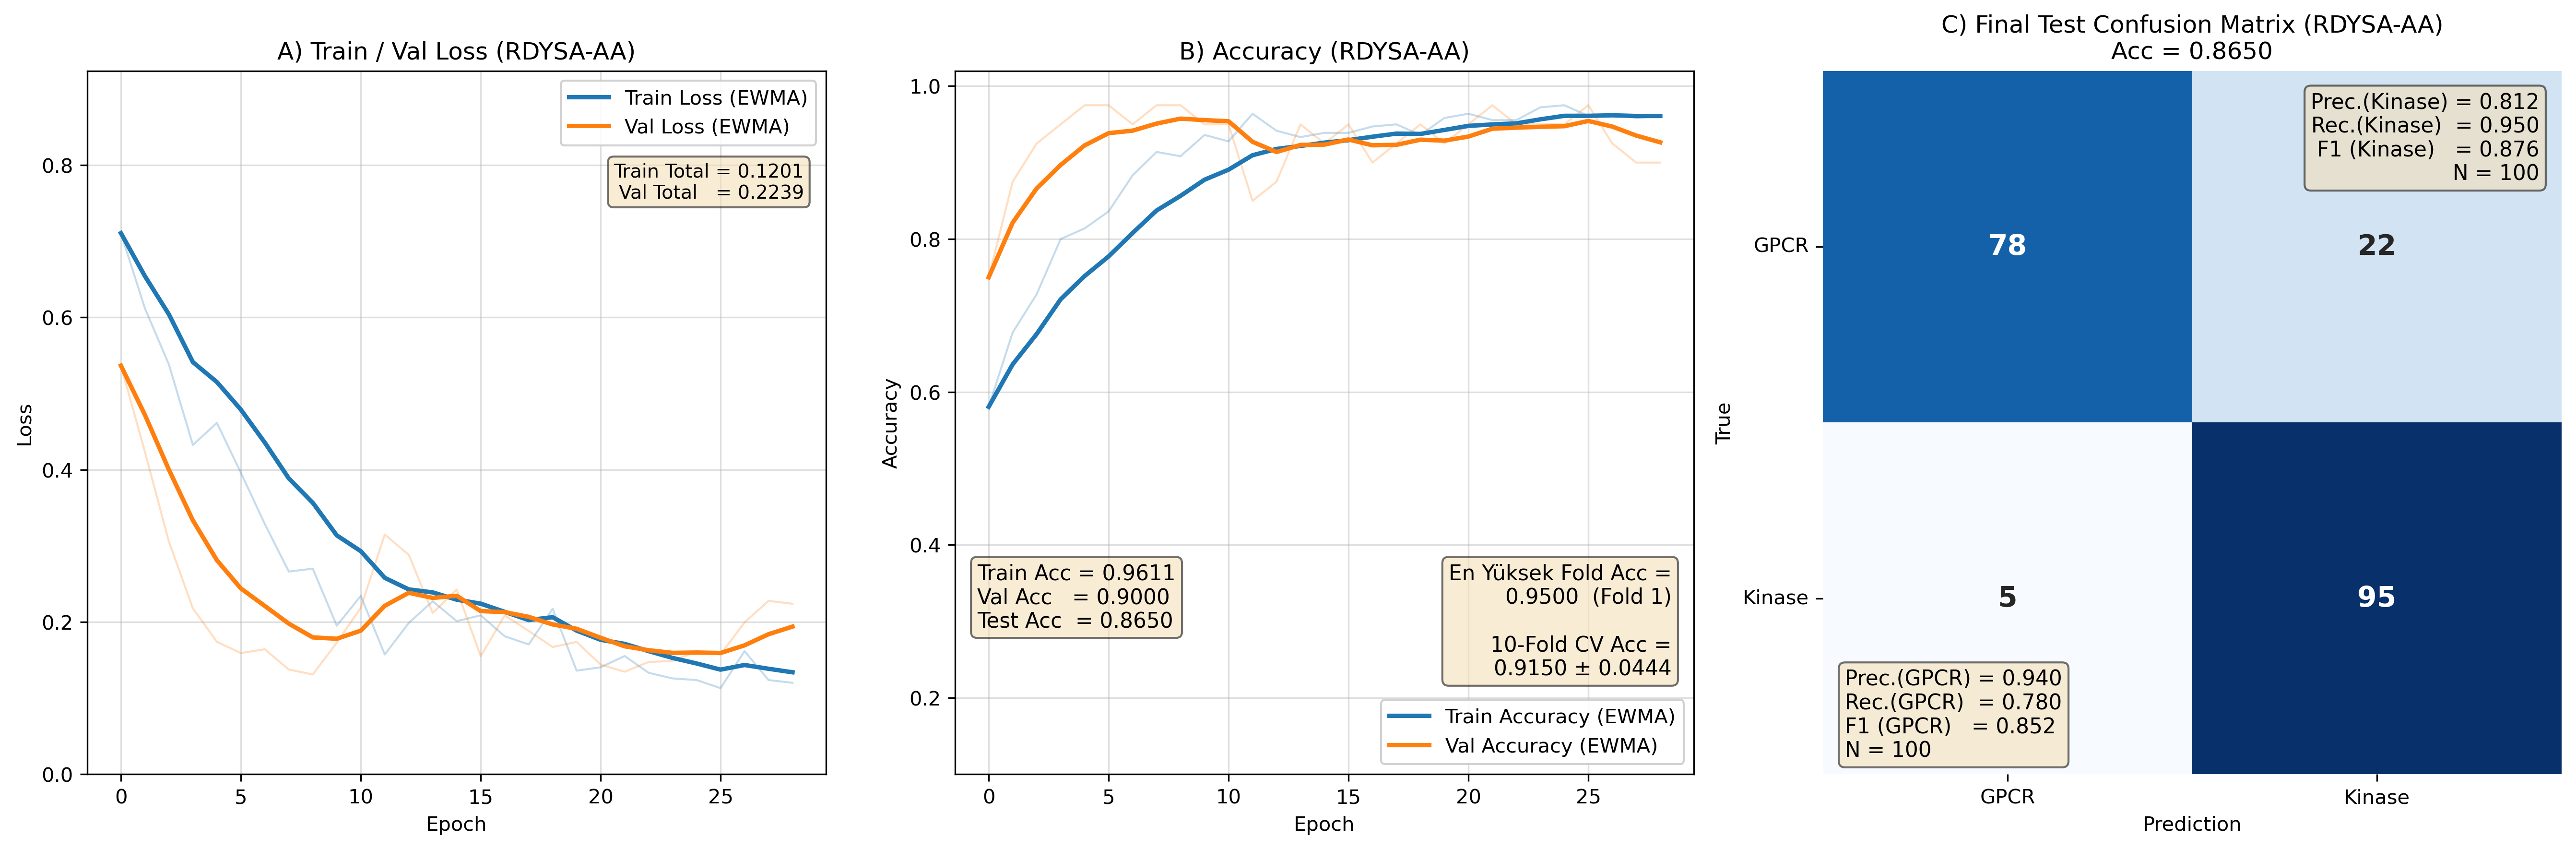

In [13]:
# =============================================================================
#   GRAFİK GÖRSELLEŞTİRME — RDYSA (Reel Değerli YSA)   [DNA / Kodon / AA ortak]
#
#   Panel A : Train / Val Loss (EWMA yumuşatmalı)
#   Panel B : Accuracy (EWMA yumuşatmalı)
#   Panel C : Confusion Matrix + sınıf bazlı metrik kutuları
#
#   
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support,
    accuracy_score, f1_score
)


# -------------------------------------------------------------------------
# 0.  Temsil etiketi  (DNA / Kodon / AA)
#     Ağ scriptindeki NPZ_YOLU'ndan otomatik algıla
# -------------------------------------------------------------------------
try:
    _kaynak = str(NPZ_YOLU).upper()
    if   "DNA"   in _kaynak: TEMSIL = "DNA"
    elif "KODON" in _kaynak: TEMSIL = "Kodon"
    elif "AA"    in _kaynak: TEMSIL = "AA"
    else:                    TEMSIL = "Reel"
except NameError:
    TEMSIL = "DNA"   # NPZ_YOLU tanımlı değilse elle


# -------------------------------------------------------------------------
# 1.  History anahtarları
# -------------------------------------------------------------------------
LOSS_KEY     = "loss"
VAL_LOSS_KEY = "val_loss"
ACC_KEY      = "accuracy"
VAL_ACC_KEY  = "val_accuracy"


# -------------------------------------------------------------------------
# 2.  EWMA yumuşatma
# -------------------------------------------------------------------------
def ewma_yumusat(dizi, alpha: float = 0.25) -> np.ndarray:
    return pd.Series(np.asarray(dizi, dtype=float)) \
             .ewm(alpha=alpha, adjust=True).mean().values


h = final_history.history
train_loss_ham = np.asarray(h[LOSS_KEY],     dtype=float)
val_loss_ham   = np.asarray(h[VAL_LOSS_KEY], dtype=float)
train_acc_ham  = np.asarray(h[ACC_KEY],      dtype=float)
val_acc_ham    = np.asarray(h[VAL_ACC_KEY],  dtype=float)

train_loss_sm = ewma_yumusat(train_loss_ham, alpha=0.25)
val_loss_sm   = ewma_yumusat(val_loss_ham,   alpha=0.25)
train_acc_sm  = ewma_yumusat(train_acc_ham,  alpha=0.25)
val_acc_sm    = ewma_yumusat(val_acc_ham,    alpha=0.25)


# -------------------------------------------------------------------------
# 3.  Son epoch değerleri
# -------------------------------------------------------------------------
train_loss_son = float(train_loss_ham[-1])
val_loss_son   = float(val_loss_ham[-1])
train_acc_son  = float(train_acc_ham[-1])
val_acc_son    = float(val_acc_ham[-1])


# -------------------------------------------------------------------------
# 4.  Test metrikleri
# -------------------------------------------------------------------------
y_true = y_test
y_pred = y_test_pred

cm  = confusion_matrix(y_true, y_pred, labels=[0, 1])
acc = accuracy_score(y_true, y_pred)

prec, rec, f1, sup = precision_recall_fscore_support(
    y_true, y_pred,
    labels=[0, 1], average=None, zero_division=0)
macro_f1_test = f1_score(y_true, y_pred, average="macro", zero_division=0)


# -------------------------------------------------------------------------
# 5.  CV özet
# -------------------------------------------------------------------------
cv_acc_mean        = cv_df["acc"].mean()
cv_acc_std         = cv_df["acc"].std(ddof=1)
cv_best_val_loss_mean = cv_df["best_val_loss"].mean()
cv_best_val_loss_std  = cv_df["best_val_loss"].std(ddof=1)
cv_best_val_acc_mean  = cv_df["best_val_acc"].mean()
cv_best_val_acc_std   = cv_df["best_val_acc"].std(ddof=1)
en_yuksek_fold_acc = cv_df["acc"].max()
en_yuksek_fold_no  = int(cv_df.loc[cv_df["acc"].idxmax(), "fold"])


# -------------------------------------------------------------------------
# 6.  Metin kutuları
# -------------------------------------------------------------------------
props = dict(boxstyle="round", facecolor="wheat", alpha=0.55)

# ── Panel A: Train / Val Total Loss ──────────────────────────────────────
text_loss = "\n".join((
    f"Train Total = {train_loss_son:.4f}",
    f"Val Total   = {val_loss_son:.4f}",
))

# ── Panel B kutu 1: Train / Val / Test Acc ───────────────────────────────
text_acc_1 = "\n".join((
    f"Train Acc = {train_acc_son:.4f}",
    f"Val Acc   = {val_acc_son:.4f}",
    f"Test Acc  = {acc:.4f}",
))

# ── Panel B kutu 2: Fold istatistikleri ──────────────────────────────────
text_acc_2 = "\n".join((
    f"En Yüksek Fold Acc =",
    f"{en_yuksek_fold_acc:.4f}  (Fold {en_yuksek_fold_no})",
    "",
    f"10-Fold CV Acc =",
    f"{cv_acc_mean:.4f} ± {cv_acc_std:.4f}",
))

# ── Panel C: Sınıf kutuları ───────────────────────────────────────────────
text_gpcr = "\n".join((
    f"Prec.(GPCR) = {prec[0]:.3f}",
    f"Rec.(GPCR)  = {rec[0]:.3f}",
    f"F1 (GPCR)   = {f1[0]:.3f}",
    f"N = {sup[0]}",
))

text_kinase = "\n".join((
    f"Prec.(Kinase) = {prec[1]:.3f}",
    f"Rec.(Kinase)  = {rec[1]:.3f}",
    f"F1 (Kinase)   = {f1[1]:.3f}",
    f"N = {sup[1]}",
))


# -------------------------------------------------------------------------
# 7.  Grafik
# -------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

C_TRAIN = "#1f77b4"
C_VAL   = "#ff7f0e"

# ==========================================================================
#  A) Train / Val Loss
# ==========================================================================
ax[0].plot(train_loss_ham, color=C_TRAIN, linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[0].plot(val_loss_ham,   color=C_VAL,   linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[0].plot(train_loss_sm,  color=C_TRAIN, linewidth=2.2,
           label="Train Loss (EWMA)")
ax[0].plot(val_loss_sm,    color=C_VAL,   linewidth=2.2,
           label="Val Loss (EWMA)")

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.4)
ax[0].legend(loc="upper right", framealpha=0.9)
ax[0].set_title(f"A) Train / Val Loss (RDYSA-{TEMSIL})")

ymax_loss = max(np.max(train_loss_ham), np.max(val_loss_ham))
ax[0].set_ylim(0.0, max(0.5, ymax_loss * 1.30))

ax[0].text(0.97, 0.87, text_loss,
           transform=ax[0].transAxes, ha="right", va="top",
           fontsize=9.5, bbox=props)

# ==========================================================================
#  B) Accuracy
# ==========================================================================
ax[1].plot(train_acc_ham, color=C_TRAIN, linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[1].plot(val_acc_ham,   color=C_VAL,   linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[1].plot(train_acc_sm,  color=C_TRAIN, linewidth=2.2,
           label="Train Accuracy (EWMA)")
ax[1].plot(val_acc_sm,    color=C_VAL,   linewidth=2.2,
           label="Val Accuracy (EWMA)")

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].grid(True, alpha=0.4)
ax[1].legend(loc="lower right", framealpha=0.9)
ax[1].set_title(f"B) Accuracy (RDYSA-{TEMSIL})")
ax[1].set_ylim(0.1, 1.02)

# Kutu 1: Train / Val / Test Acc — sol alt
ax[1].text(0.03, 0.30, text_acc_1,
           transform=ax[1].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)

# Kutu 2: Fold istatistikleri — sağ alt
ax[1].text(0.97, 0.30, text_acc_2,
           transform=ax[1].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

# ==========================================================================
#  C) Confusion Matrix
# ==========================================================================
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            cbar=False, ax=ax[2],
            annot_kws={"size": 14, "weight": "bold"})

ax[2].set_xlabel("Prediction")
ax[2].set_ylabel("True")
ax[2].set_title(
    f"C) Final Test Confusion Matrix (RDYSA-{TEMSIL})\nAcc = {acc:.4f}")
ax[2].set_xticklabels([SINIF_ADLARI.get(0, "0"), SINIF_ADLARI.get(1, "1")])
ax[2].set_yticklabels([SINIF_ADLARI.get(0, "0"), SINIF_ADLARI.get(1, "1")],
                      rotation=0)

ax[2].text(0.03, 0.15, text_gpcr,
           transform=ax[2].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)
ax[2].text(0.97, 0.97, text_kinase,
           transform=ax[2].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

plt.tight_layout()
plt.savefig(f"reel_ag_{TEMSIL.lower()}_train_val_test_sonuclari.png",
            dpi=600, bbox_inches="tight")
plt.show()